# Statistical and PCA Analysis
### This notebook will perfrom an SVM analysis of the cleaned and formated data

March 5th, 2025

Maxime Bouthillier

In [85]:
import pandas as pd
import os 
from joblib import load
from sklearn import svm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [86]:
directory = '/mnt/hpc/work/mbouthil/Research_Project/MIMIC-III_data'
os.chdir(directory)

df = load("Master_Dataframe_reduced.joblib") # Reduced Dataset

In [87]:
# Altering column values to integer (categorical) or float objects
for col, col_values in df.items():
    # if df[col].dtype == ('O'):
    #    df[col] = df[col].astype('category').cat.codes

    if df[col].dtype == ('<m8[ns]'):
        df[col] = df[col].dt.total_seconds()
        df[col] = df[col]/(60**2*24)

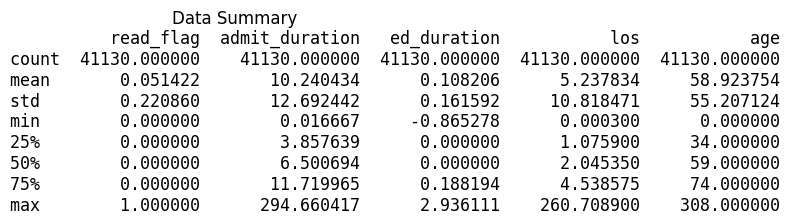

In [88]:
summary = df.describe()
summary_str = summary.to_string()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 2))
fig.suptitle("Data Summary")
ax.text(0, 1, summary_str, fontsize=12, family='monospace', va='top')
ax.axis('off')
plt.show()

In [89]:
print('Out of all %.2f observations, with %.2f percent are instances of readmissions' % (len(df['read_flag']), sum(df['read_flag'])/ len(df['read_flag'])*100))

Out of all 41130.00 observations, with 5.14 percent are instances of readmissions


In [90]:
sum(df['read_flag'])

2115.0

# Visualizations

/tmp/ipykernel_109067/569102051.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(list((df['ethnicity']).unique()),rotation=90)


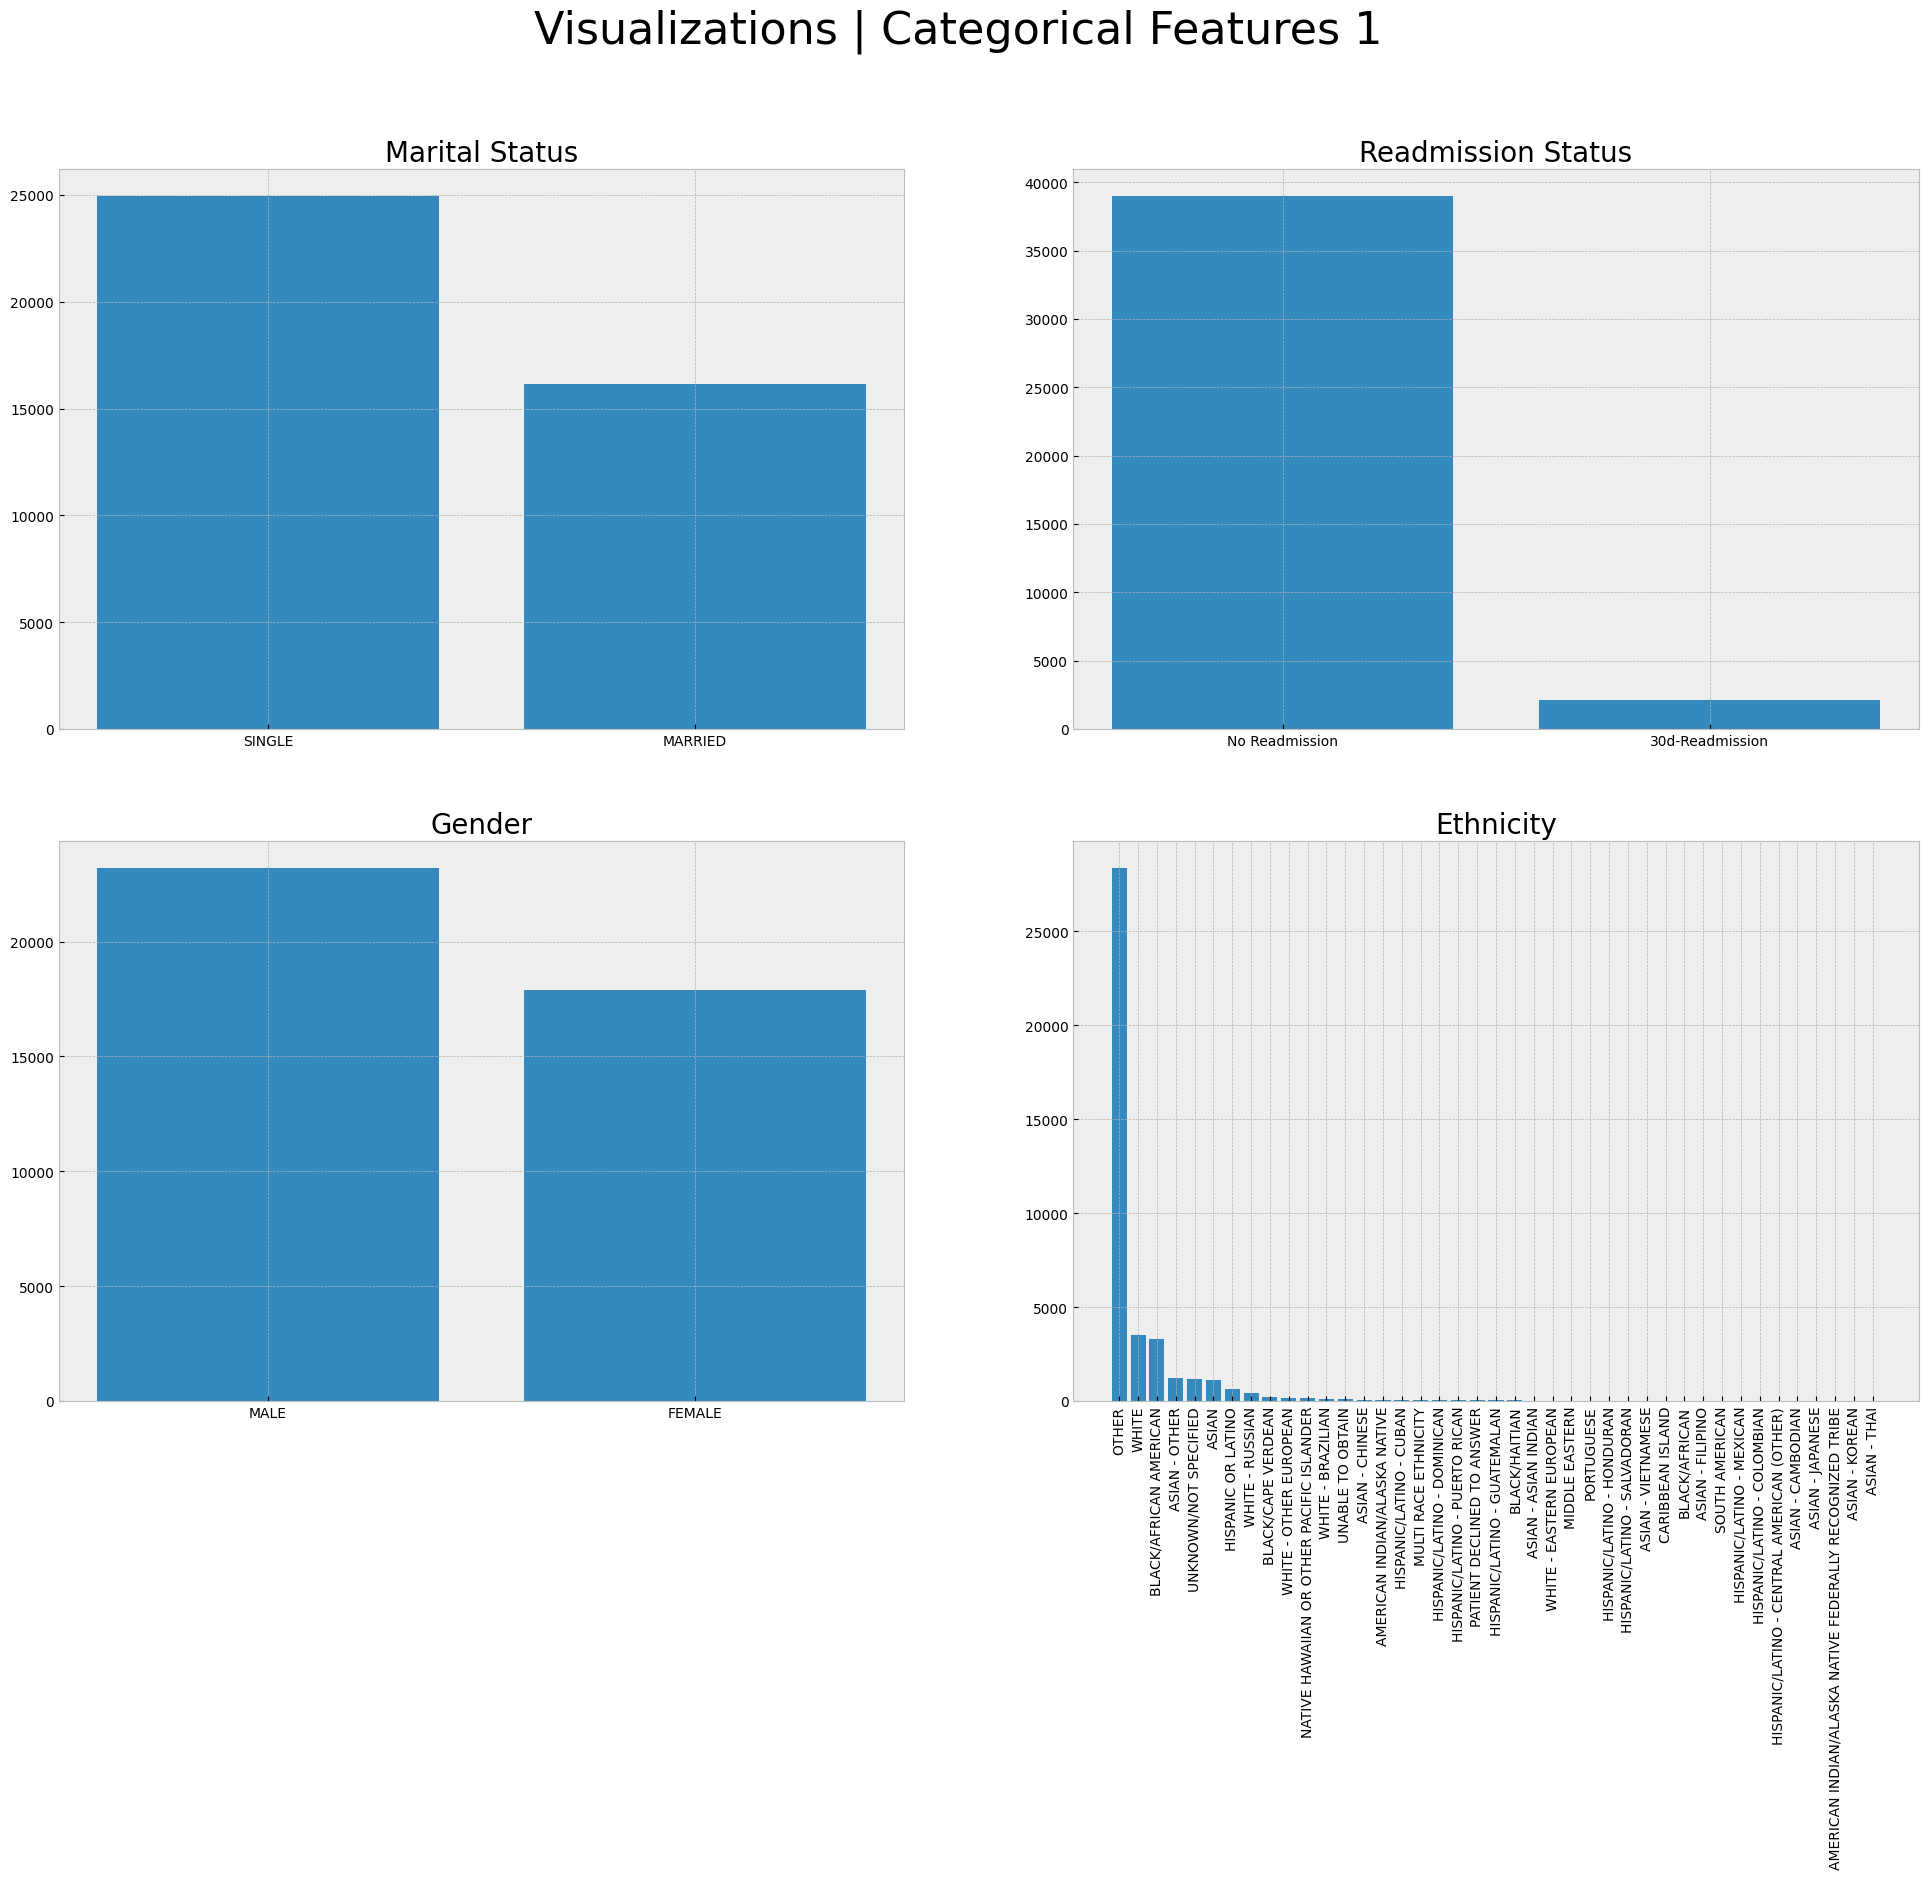

In [91]:
fig, ax = plt.subplots(2,2, figsize=(24,16))
fig.suptitle('Visualizations | Categorical Features 1', fontsize=32)

# Marital Status
matrital_count = df['marital_status'].value_counts()
ax[0,0].bar(matrital_count.index, matrital_count.values)
ax[0,0].set_title('Marital Status', fontsize=20)  

# Readmission
read_count = df['read_flag'].value_counts()
ax[0,1].bar(read_count.index, read_count.values)
labels = ['No Readmission', '30d-Readmission']
ax[0,1].set_xticks([0,1])
ax[0,1].set_xticklabels(labels)
ax[0,1].set_title('Readmission Status', fontsize=20)  


# Gender
gender_count = df['gender'].value_counts()
ax[1,0].bar(gender_count.index, gender_count.values)
labels = ['MALE', 'FEMALE']
ax[1,0].set_xticks([0,1])
ax[1,0].set_xticklabels(labels)
ax[1,0].set_title('Gender', fontsize=20)  

# Ethnicity
ethnicity_count = df['ethnicity'].value_counts()
ax[1,1].bar(ethnicity_count.index, ethnicity_count.values)
ax[1,1].set_xticklabels(list((df['ethnicity']).unique()),rotation=90)
ax[1,1].set_title('Ethnicity', fontsize=20)  

plt.style.use('bmh')
plt.show()

/tmp/ipykernel_109067/71409821.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,0].set_xticklabels(list((df['admission_location']).unique()),rotation=90)
/tmp/ipykernel_109067/71409821.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(list((df['discharge_location']).unique()),rotation=90)


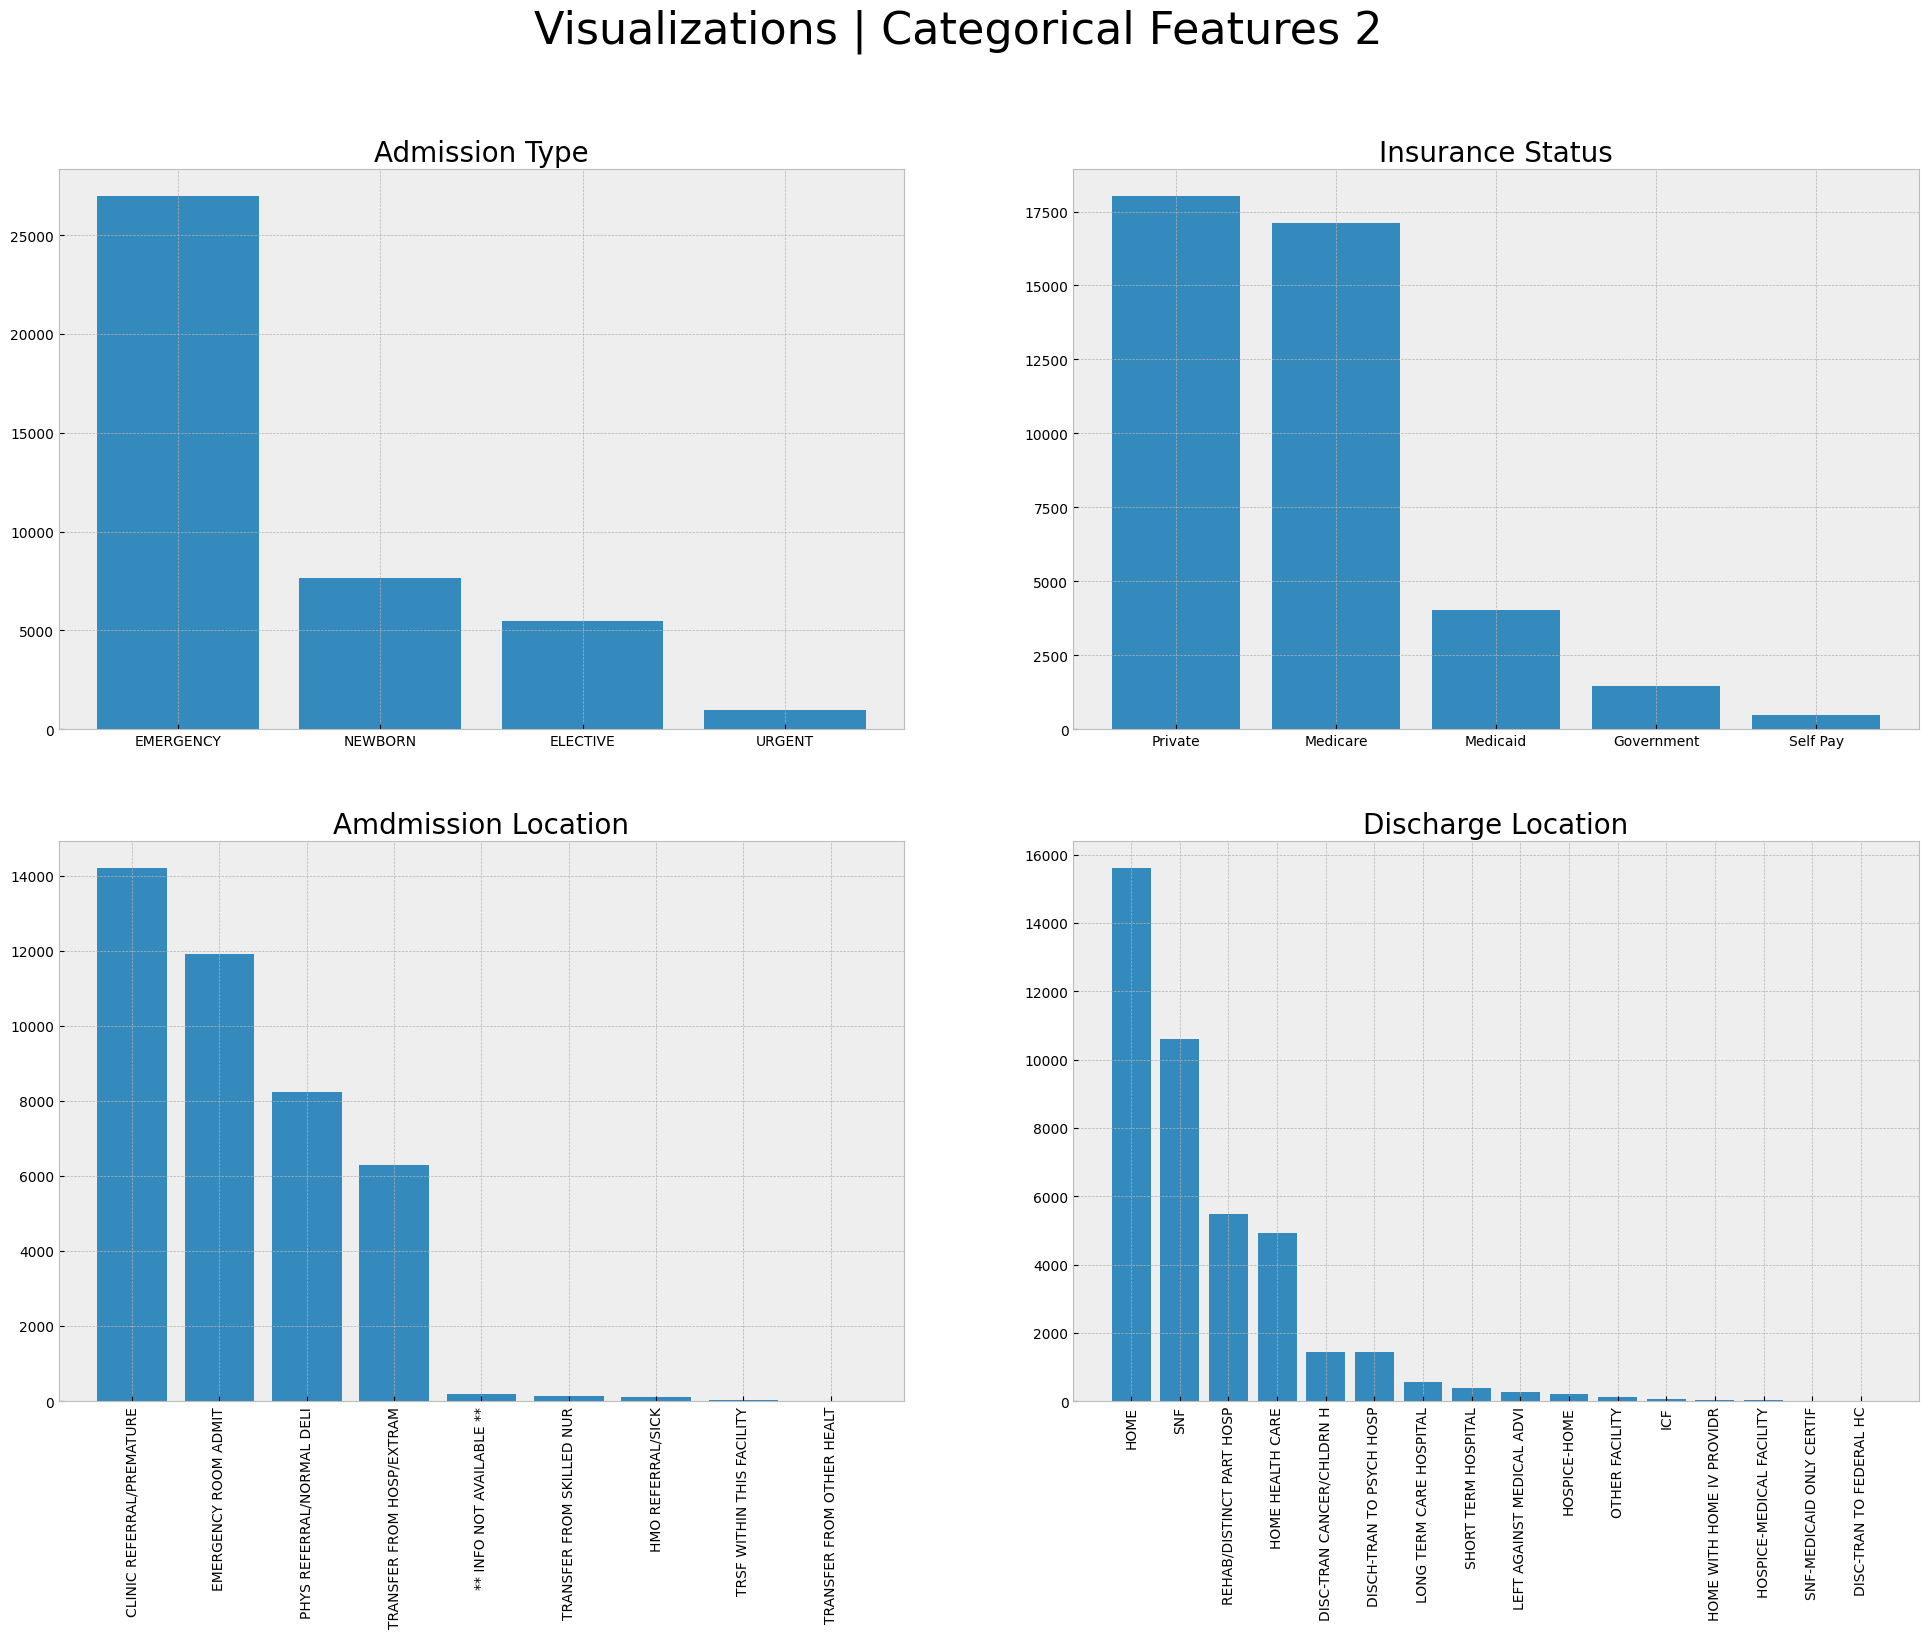

In [92]:
fig, ax = plt.subplots(2,2, figsize=(24,16))
fig.suptitle('Visualizations | Categorical Features 2', fontsize=32)


# Admit type
admit_type_count = df['admission_type'].value_counts()
ax[0,0].bar(admit_type_count.index, admit_type_count.values)
ax[0,0].set_title('Admission Type', fontsize=20)  

# insurance
insurance_count = df['insurance'].value_counts()
ax[0,1].bar(insurance_count.index, insurance_count.values)
ax[0,1].set_title('Insurance Status', fontsize=20)  

# Locations:
admit_loc_count = df['admission_location'].value_counts()
ax[1,0].bar(admit_loc_count.index, admit_loc_count.values)
ax[1,0].set_xticklabels(list((df['admission_location']).unique()),rotation=90)
ax[1,0].set_title('Amdmission Location', fontsize=20)

disch_loc_count = df['discharge_location'].value_counts()
ax[1,1].bar(disch_loc_count.index, disch_loc_count.values)
ax[1,1].set_xticklabels(list((df['discharge_location']).unique()),rotation=90)
ax[1,1].set_title('Discharge Location', fontsize=20)

plt.style.use('bmh')
plt.show()

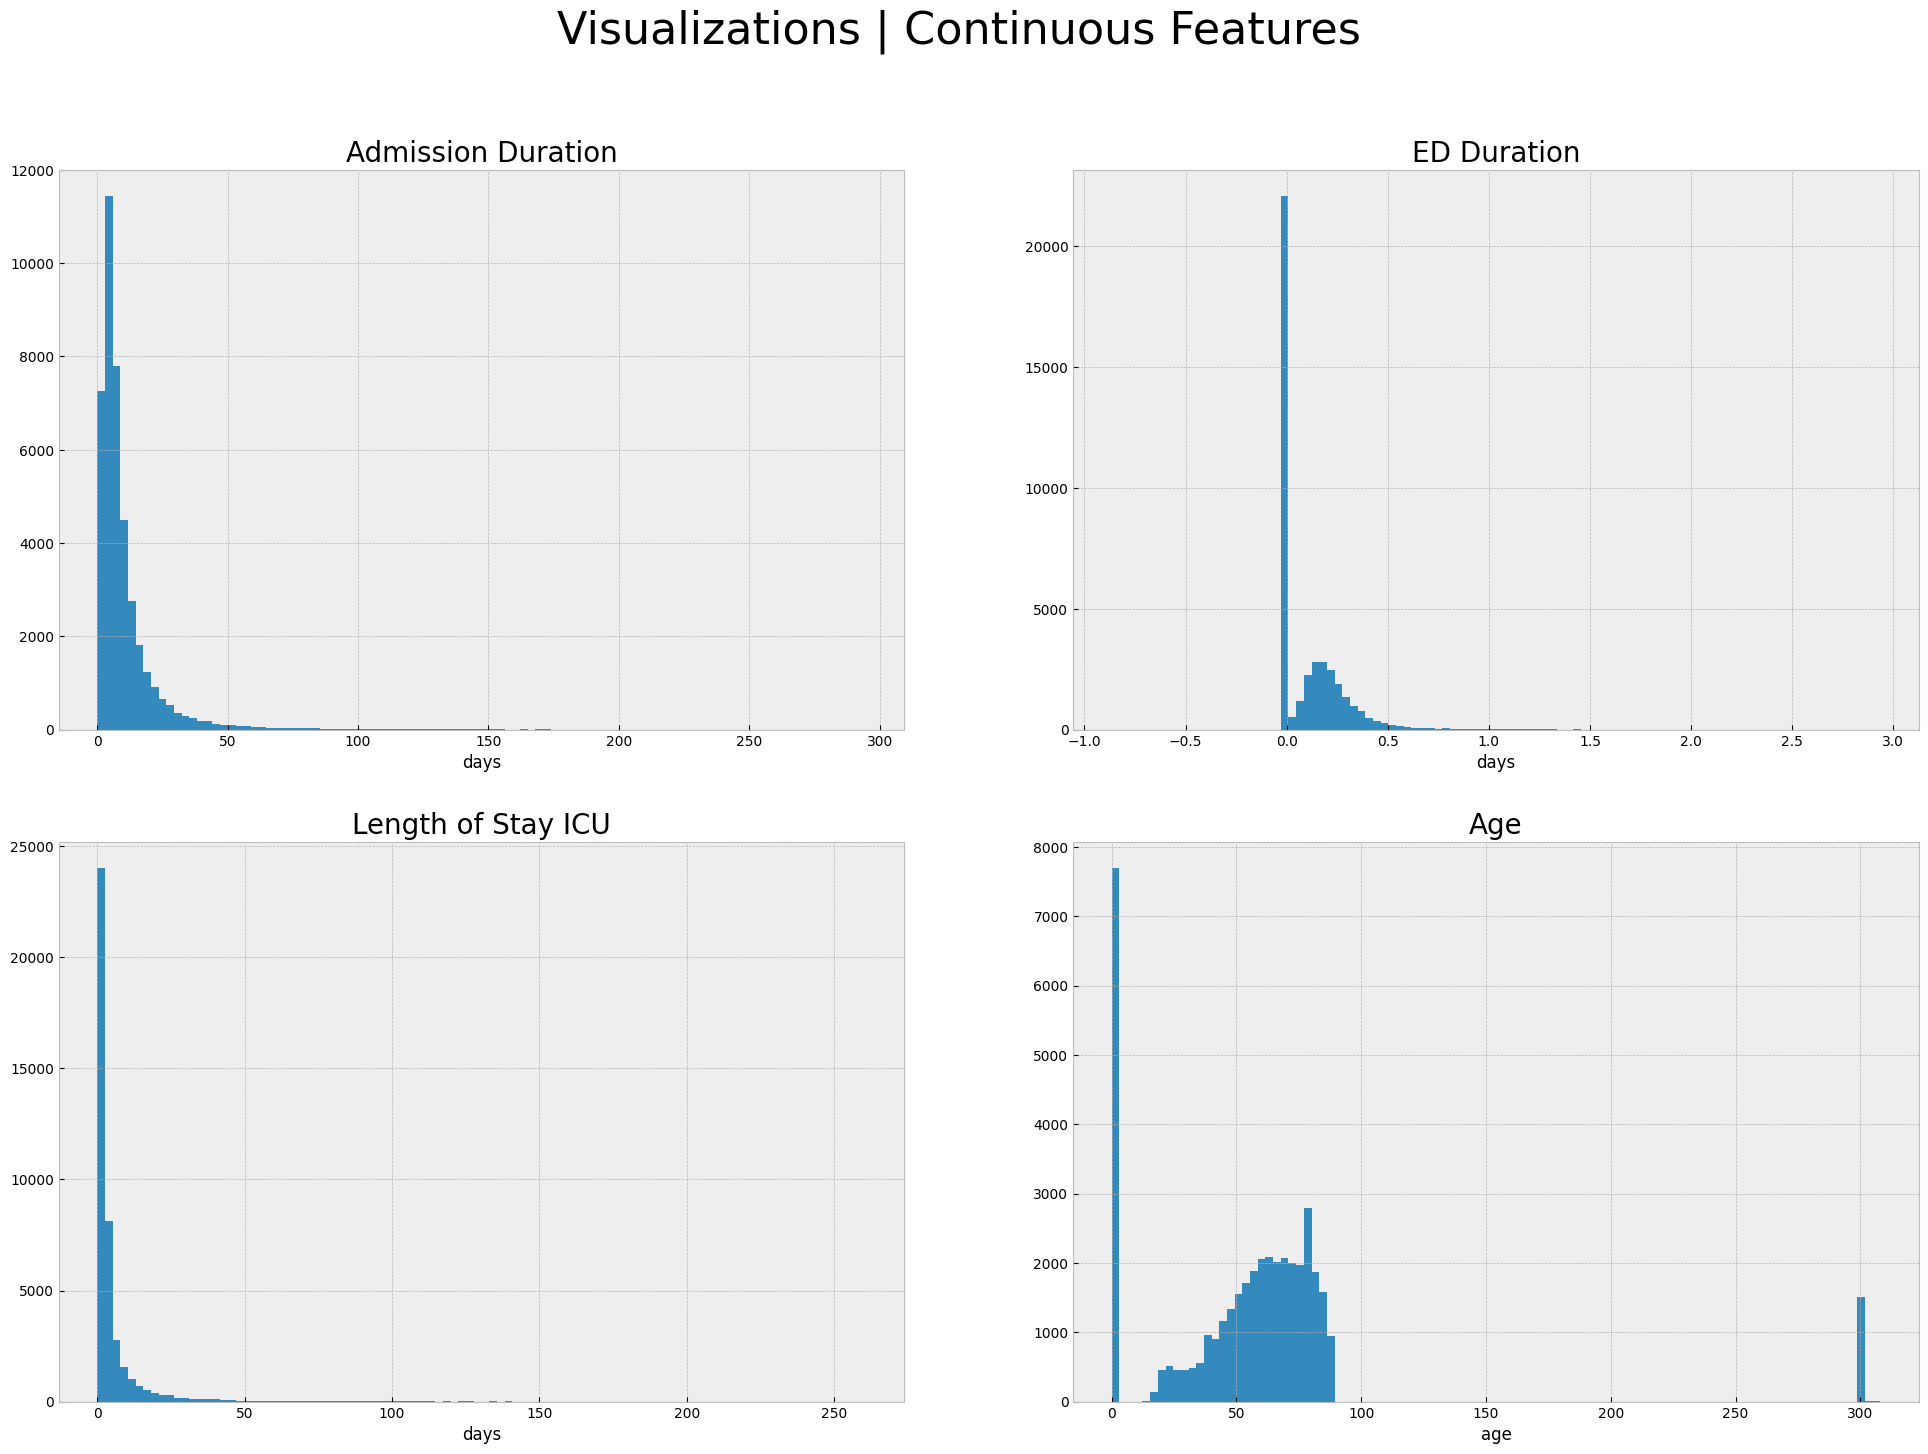

In [93]:
fig, ax = plt.subplots(2,2, figsize=(24,16))
fig.suptitle('Visualizations | Continuous Features', fontsize=32)

# Admit Duration
ax[0,0].hist(df['admit_duration'], bins=100)
ax[0,0].set_title('Admission Duration', fontsize=20)         
ax[0,0].set_xlabel('days')

# ED Duration
ax[0,1].hist(df['ed_duration'], bins=100)
ax[0,1].set_title('ED Duration', fontsize=20)  
ax[0,1].set_xlabel('days') 

# LOS
ax[1,0].hist(df['los'], bins=100)
ax[1,0].set_title('Length of Stay ICU', fontsize=20)     
ax[1,0].set_xlabel('days')

# Age
ax[1,1].hist(df['age'], bins=100)
ax[1,1].set_title('Age', fontsize=20)  
ax[1,1].set_xlabel('age')

plt.style.use('bmh')
plt.show()

# Data Alterations

In [94]:
# Data Alterations:
df['ed_duration'] = df['ed_duration'].clip(lower=0) # imputing 0 ED duration for negative entries

# Removing Ages and Births
df = df[df['age'] <= 100]
df = df[df['age'] >= 1]

# Capping length of stay
df = df[df['los'] <= 30]
df = df[df['admit_duration'] <= 30]
df = df[df['ed_duration'] <= 1]
df['ed_duration'] = df['ed_duration'].clip(lower=0) # imputing 0 ED duration for negative entries

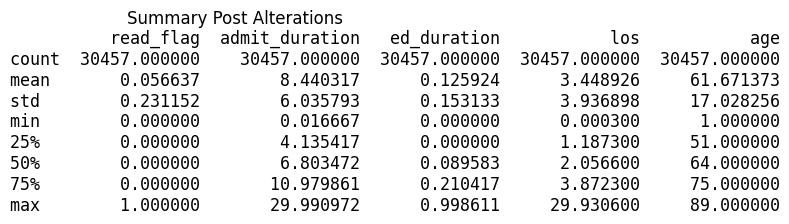

In [95]:
summary = df.describe()
summary_str = summary.to_string()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 2))
fig.suptitle("Summary Post Alterations")
ax.text(0, 1, summary_str, fontsize=12, family='monospace', va='top')
ax.axis('off')
plt.show()

In [96]:
print('After the outlier removal, there are %.2f observations, with %.2f percent are instances of readmissions' % (len(df['read_flag']), sum(df['read_flag'])/ len(df['read_flag'])*100))

After the outlier removal, there are 30457.00 observations, with 5.66 percent are instances of readmissions


In [97]:
sum(df['read_flag'])

1725.0

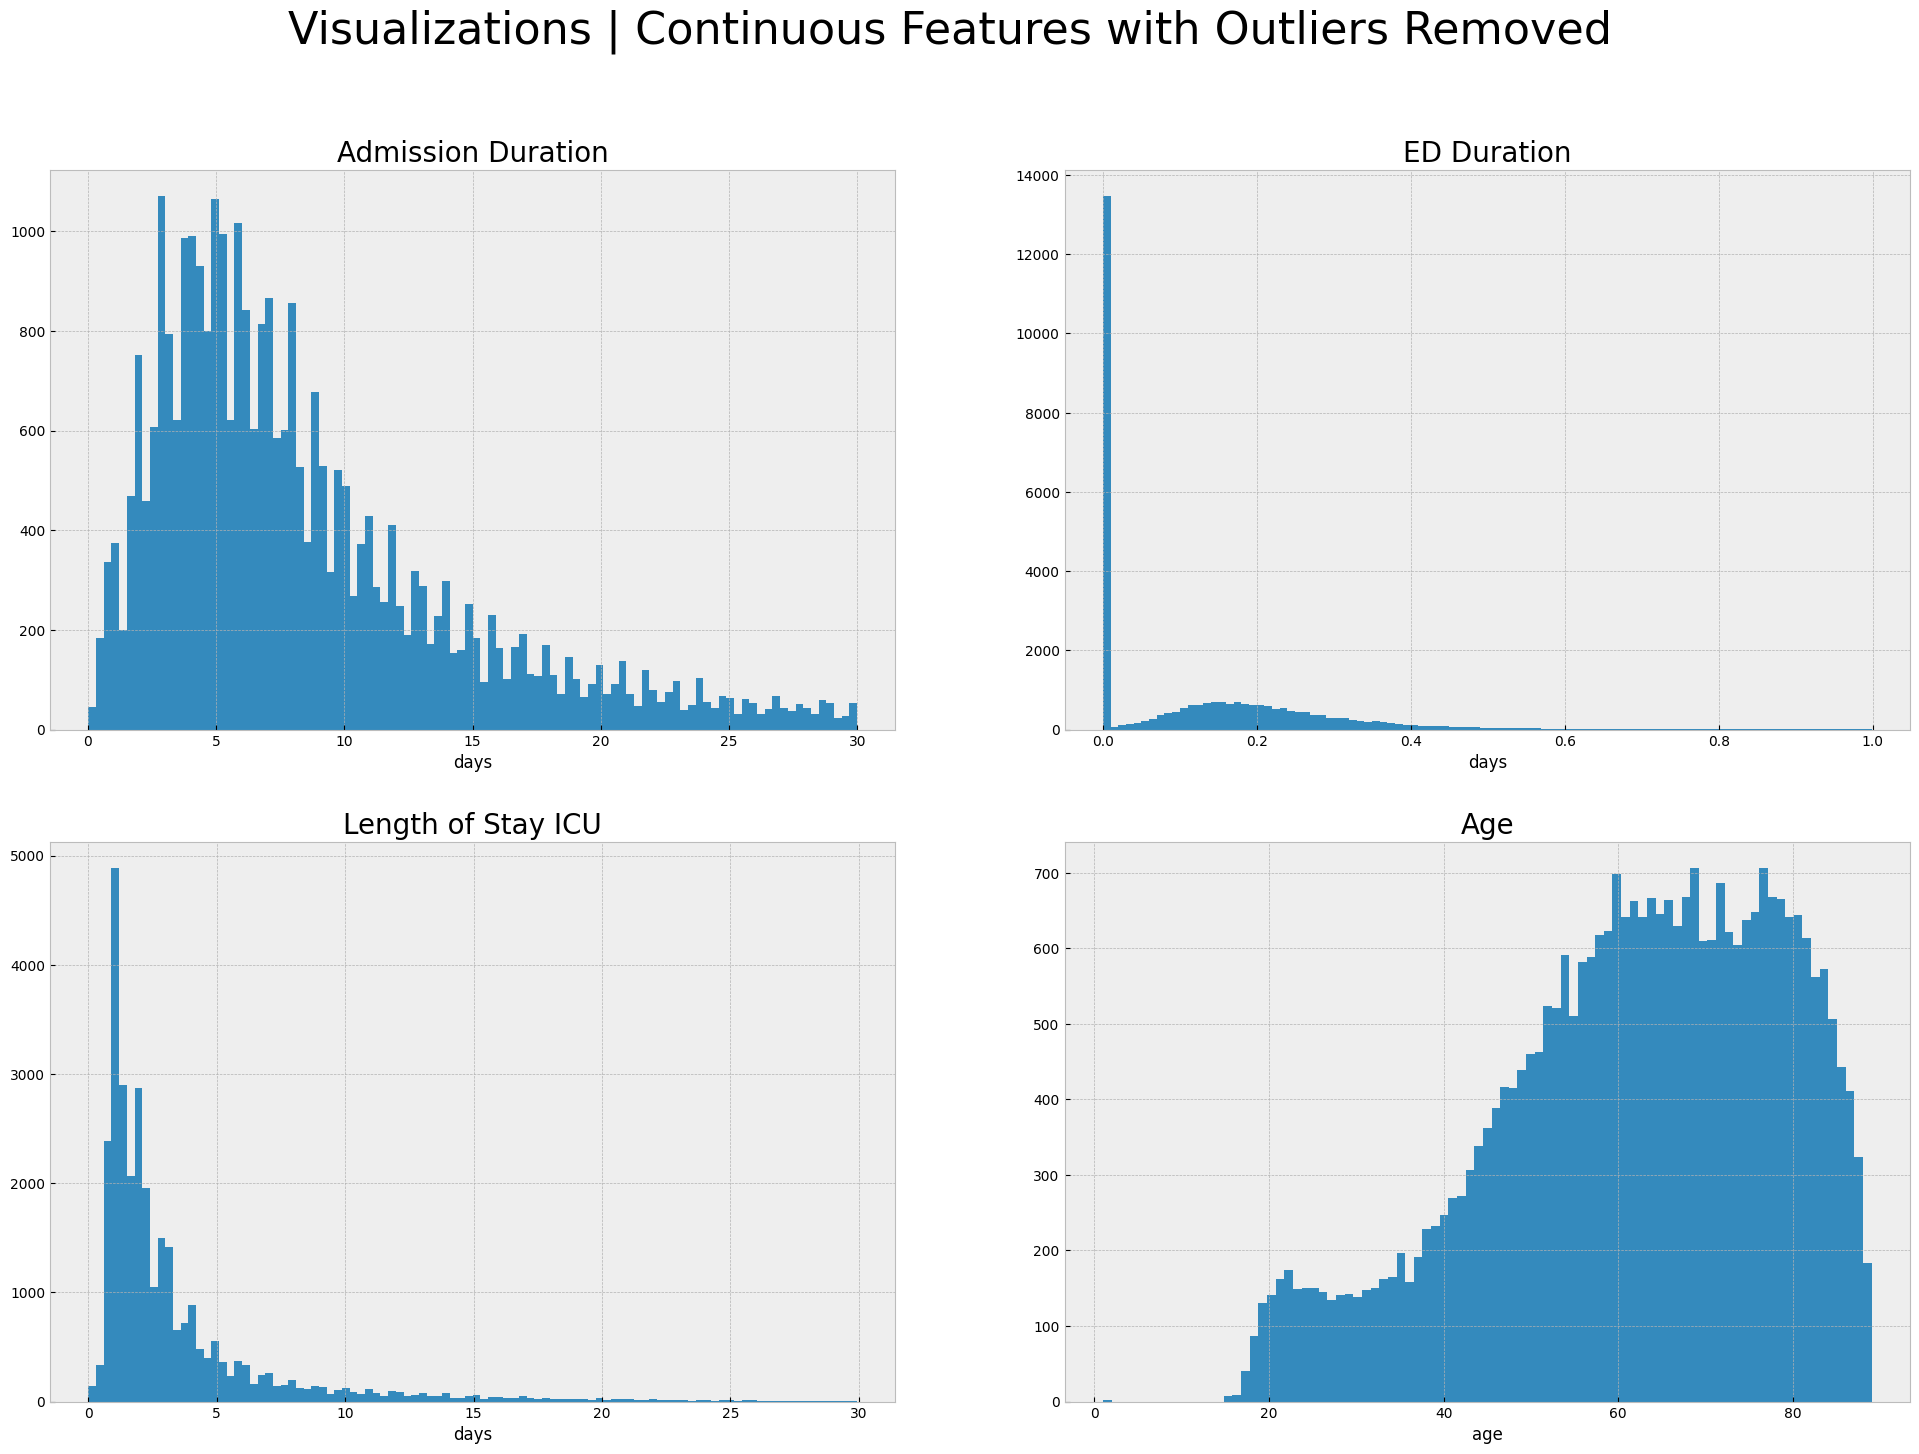

In [98]:
fig, ax = plt.subplots(2,2, figsize=(24,16))
fig.suptitle('Visualizations | Continuous Features with Outliers Removed', fontsize=32)

# Admit Duration
ax[0,0].hist(df['admit_duration'], bins=100)
ax[0,0].set_title('Admission Duration', fontsize=20)         
ax[0,0].set_xlabel('days')

# ED Duration
ax[0,1].hist(df['ed_duration'], bins=100)
ax[0,1].set_title('ED Duration', fontsize=20)  
ax[0,1].set_xlabel('days') 

# LOS
ax[1,0].hist(df['los'], bins=100)
ax[1,0].set_title('Length of Stay ICU', fontsize=20)     
ax[1,0].set_xlabel('days')

# Age
ax[1,1].hist(df['age'], bins=89)
ax[1,1].set_title('Age', fontsize=20)  
ax[1,1].set_xlabel('age')

plt.style.use('bmh')
plt.show()

/tmp/ipykernel_109067/3315654155.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(list((df['ethnicity']).unique()),rotation=90)


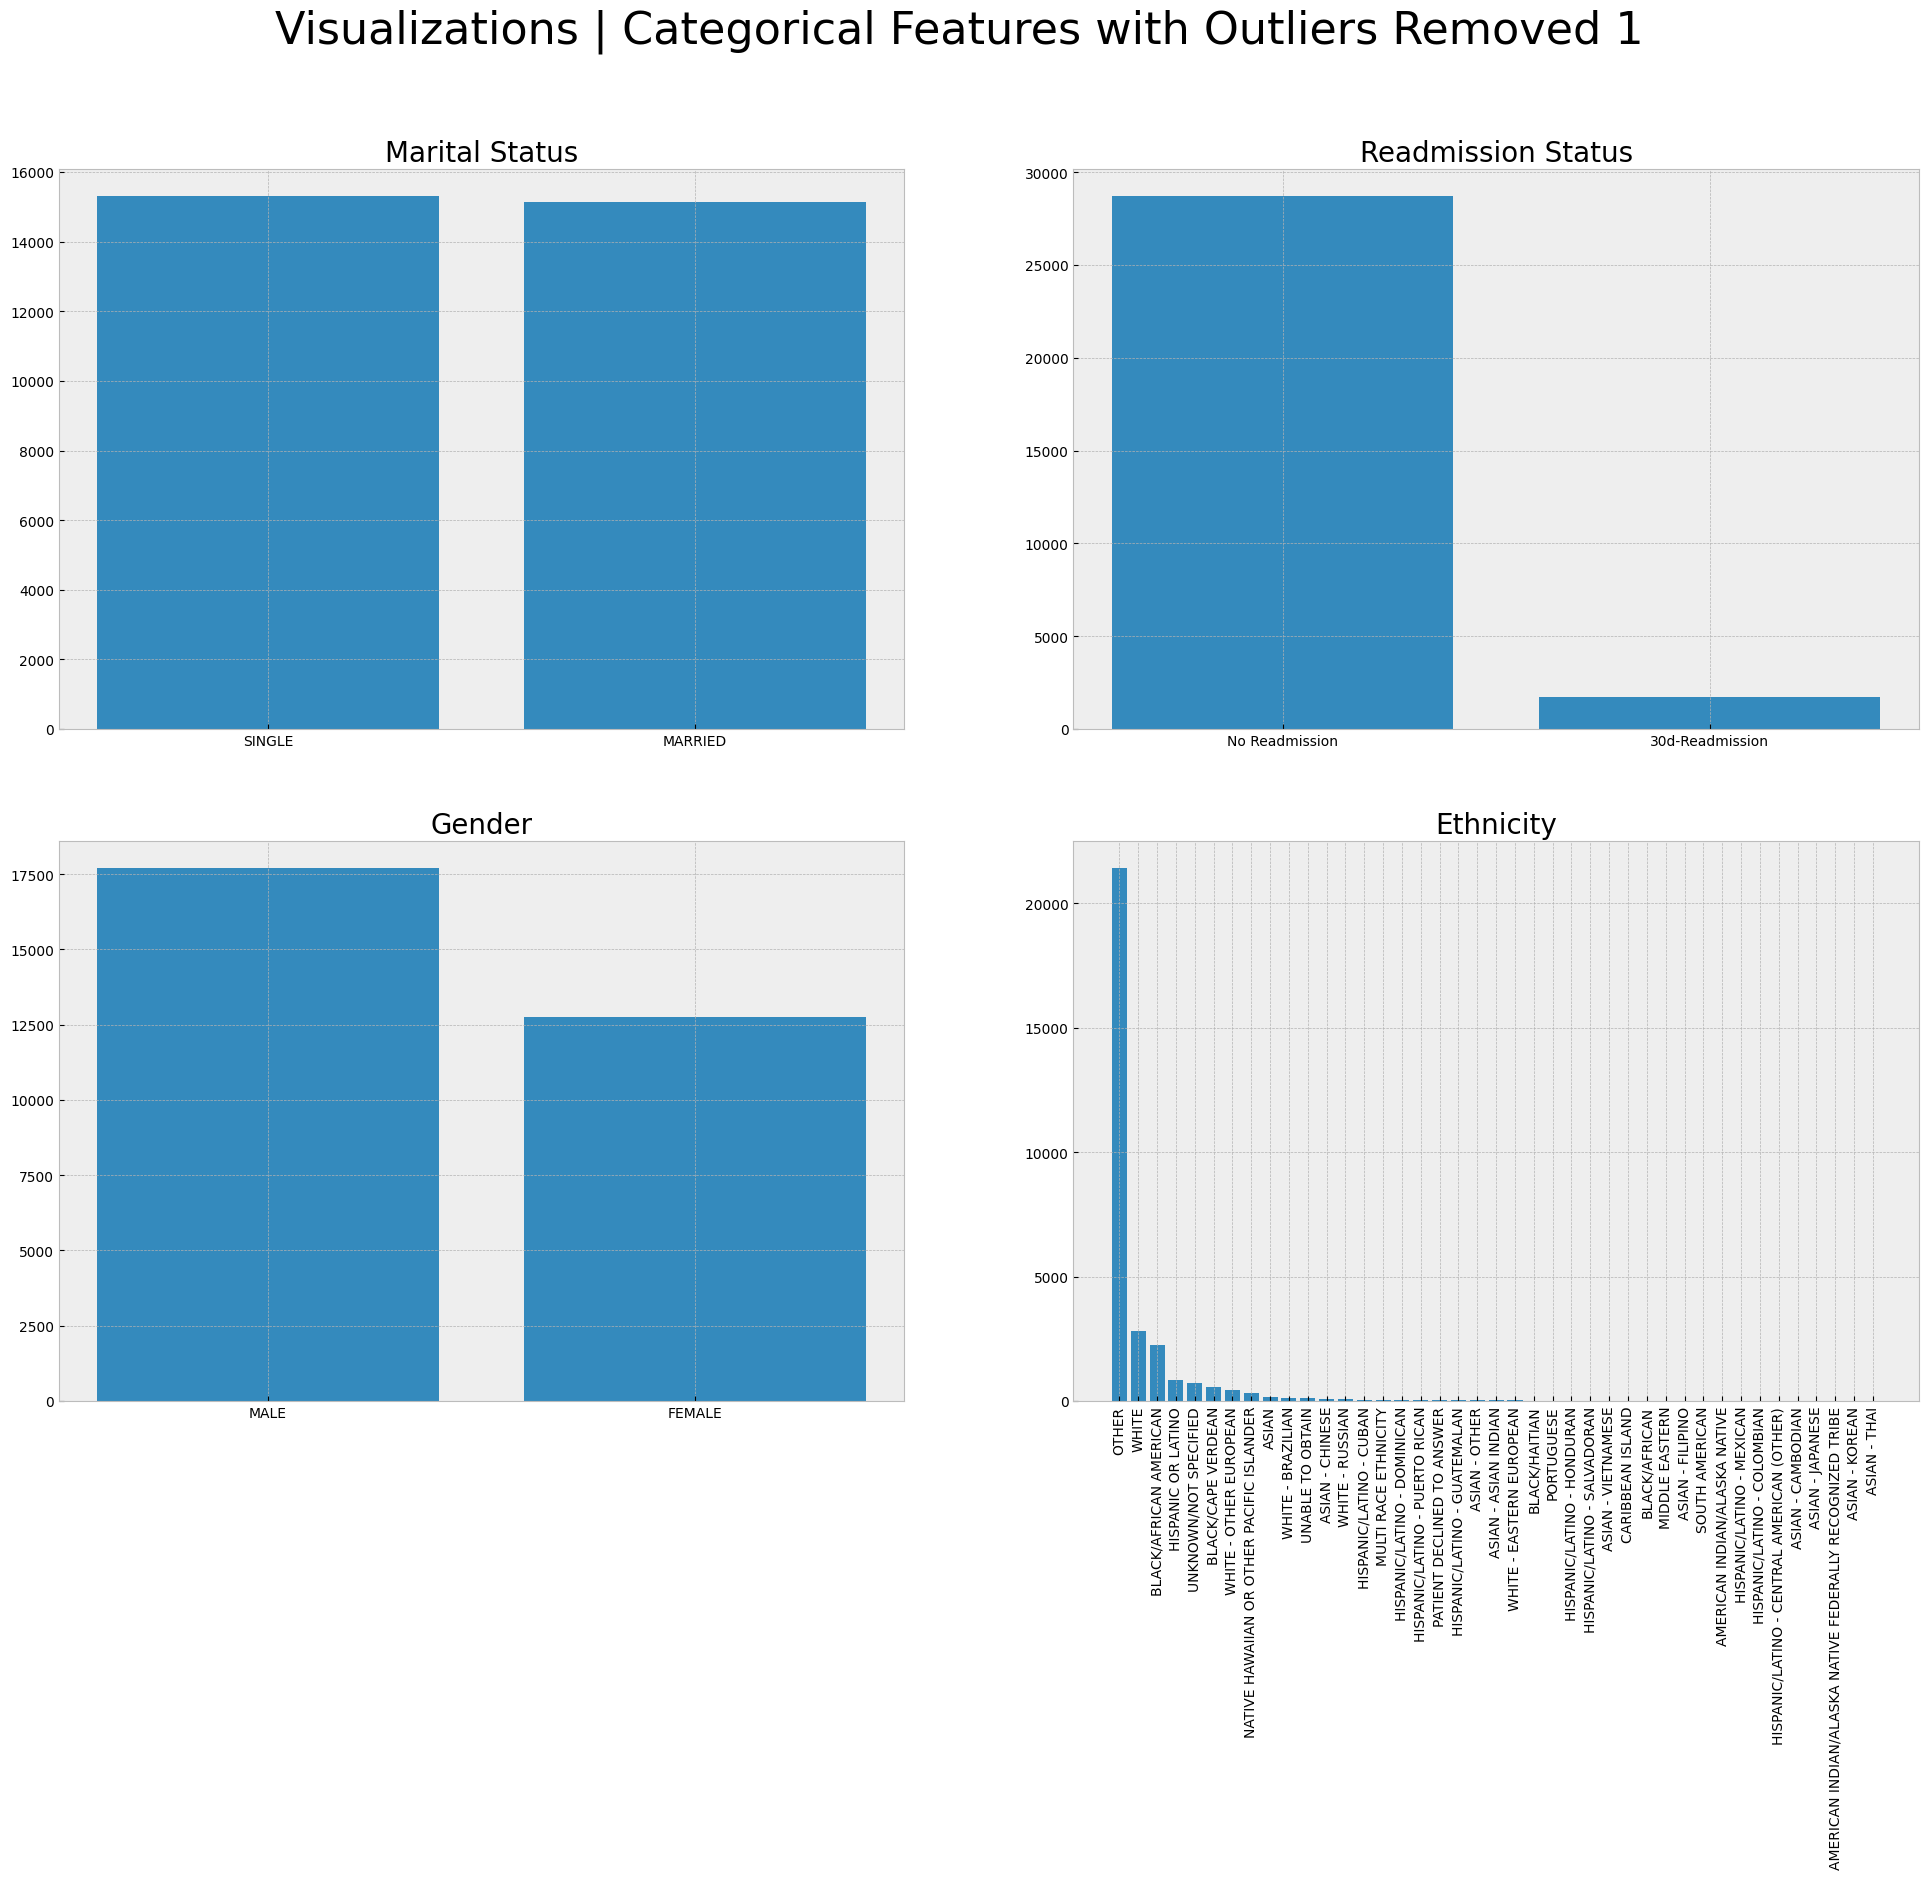

In [99]:
fig, ax = plt.subplots(2,2, figsize=(24,16))
fig.suptitle('Visualizations | Categorical Features with Outliers Removed 1', fontsize=32)

# Marital Status
matrital_count = df['marital_status'].value_counts()
ax[0,0].bar(matrital_count.index, matrital_count.values)
ax[0,0].set_title('Marital Status', fontsize=20)  

# Readmission
read_count = df['read_flag'].value_counts()
ax[0,1].bar(read_count.index, read_count.values)
labels = ['No Readmission', '30d-Readmission']
ax[0,1].set_xticks([0,1])
ax[0,1].set_xticklabels(labels)
ax[0,1].set_title('Readmission Status', fontsize=20)  


# Gender
gender_count = df['gender'].value_counts()
ax[1,0].bar(gender_count.index, gender_count.values)
labels = ['MALE', 'FEMALE']
ax[1,0].set_xticks([0,1])
ax[1,0].set_xticklabels(labels)
ax[1,0].set_title('Gender', fontsize=20)  

# Ethnicity
ethnicity_count = df['ethnicity'].value_counts()
ax[1,1].bar(ethnicity_count.index, ethnicity_count.values)
ax[1,1].set_xticklabels(list((df['ethnicity']).unique()),rotation=90)
ax[1,1].set_title('Ethnicity', fontsize=20)  

plt.style.use('bmh')
plt.show()

/tmp/ipykernel_109067/2801535508.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,0].set_xticklabels(list((df['admission_location']).unique()),rotation=90)
/tmp/ipykernel_109067/2801535508.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(list((df['discharge_location']).unique()),rotation=90)


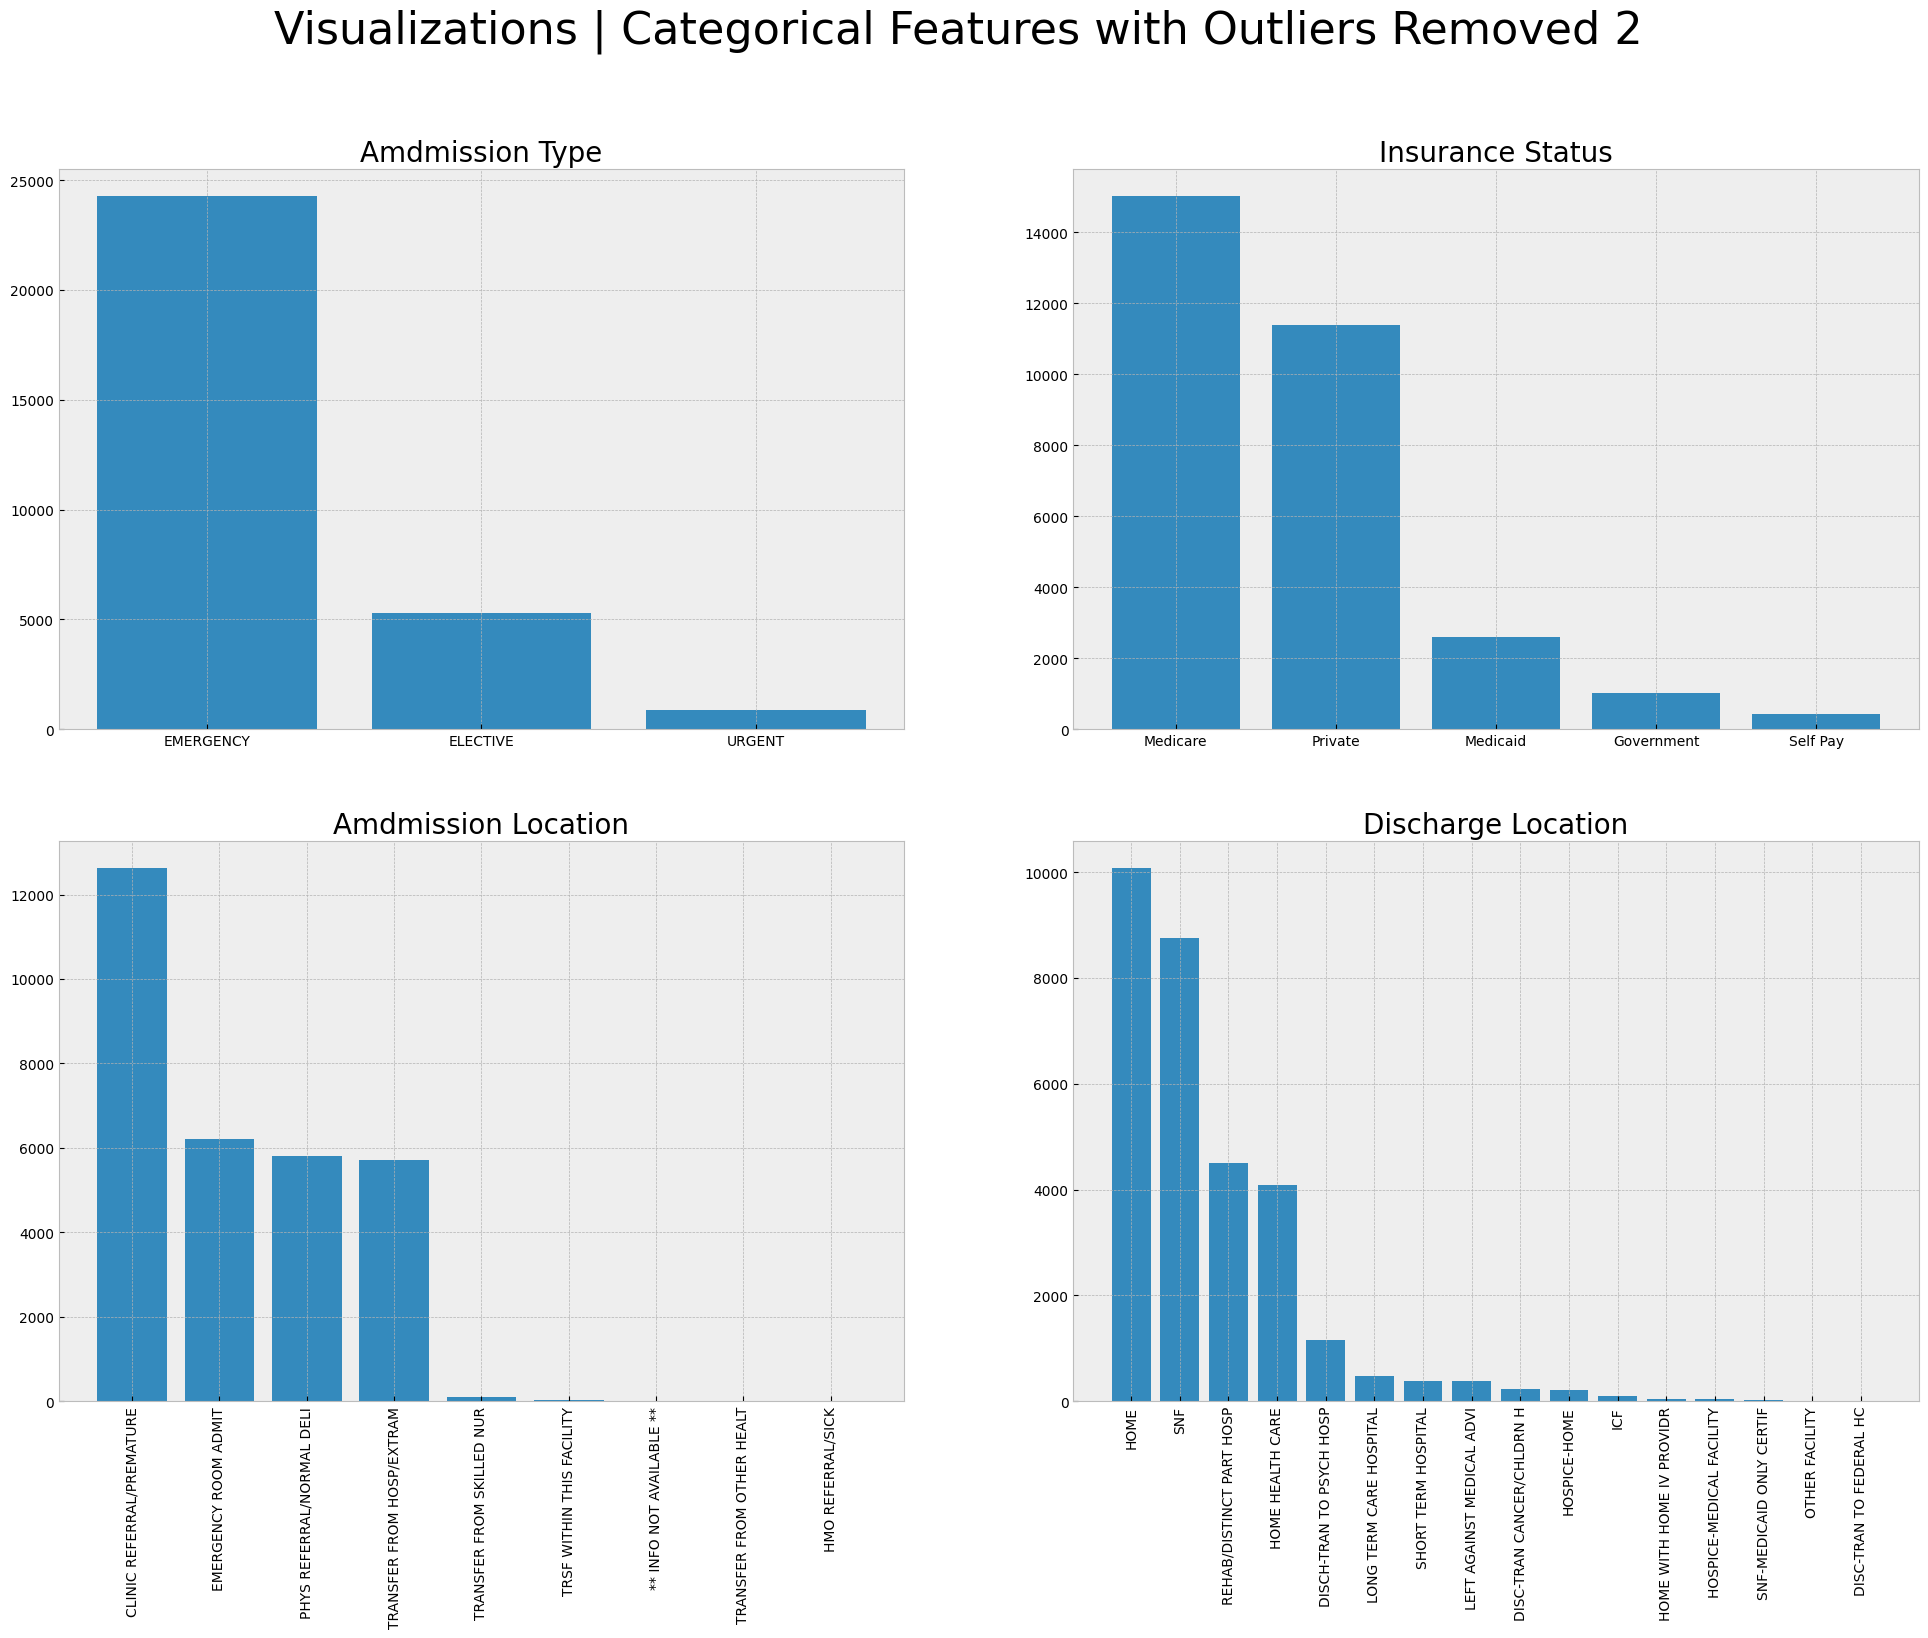

In [100]:
fig, ax = plt.subplots(2,2, figsize=(24,16))
fig.suptitle('Visualizations | Categorical Features with Outliers Removed 2', fontsize=32)


# Admit type
admit_type_count = df['admission_type'].value_counts()
ax[0,0].bar(admit_type_count.index, admit_type_count.values)
ax[0,0].set_title('Amdmission Type', fontsize=20)  

# insurance
insurance_count = df['insurance'].value_counts()
ax[0,1].bar(insurance_count.index, insurance_count.values)
ax[0,1].set_title('Insurance Status', fontsize=20)  

# Locations:
admit_loc_count = df['admission_location'].value_counts()
ax[1,0].bar(admit_loc_count.index, admit_loc_count.values)
ax[1,0].set_xticklabels(list((df['admission_location']).unique()),rotation=90)
ax[1,0].set_title('Amdmission Location', fontsize=20)

disch_loc_count = df['discharge_location'].value_counts()
ax[1,1].bar(disch_loc_count.index, disch_loc_count.values)
ax[1,1].set_xticklabels(list((df['discharge_location']).unique()),rotation=90)
ax[1,1].set_title('Discharge Location', fontsize=20)

plt.style.use('bmh')
plt.show()

# PCA Recued Spaces

### Further Data Alterations

In [101]:
df = df.drop('ethnicity', axis=1)

# Altering column values to integer (categorical) or float objects
for col, col_values in df.items():
    if df[col].dtype == ('O'):
        df[col] = df[col].astype('category').cat.codes

### Time in Seconds

In [102]:
# Making the time in seconds
df['los'] = df['los']*(60**2*24)
df['admit_duration'] = df['admit_duration']*(60**2*24)
df['ed_duration'] = df['ed_duration']*(60**2*24)

y = df['read_flag']
X = df.drop('read_flag', axis=1)

pca_s = PCA(n_components=2)
X_pca_s = pca_s.fit_transform(X)

### Time in minutes

In [103]:
# Seconds to minutes
df['los'] = df['los']/60
df['admit_duration'] = df['admit_duration']/60
df['ed_duration'] = df['ed_duration']/60

y = df['read_flag']
X = df.drop('read_flag', axis=1)

pca_m = PCA(n_components=2)
X_pca_m = pca_m.fit_transform(X)

### Time in hours

In [104]:
# Minutes to hours
df['los'] = df['los']/60
df['admit_duration'] = df['admit_duration']/60
df['ed_duration'] = df['ed_duration']/60

y = df['read_flag']
X = df.drop('read_flag', axis=1)

pca_h = PCA(n_components=2)
X_pca_h = pca_h.fit_transform(X)

### Time in days

In [105]:
# Hours to days
df['los'] = df['los']/24
df['admit_duration'] = df['admit_duration']/24
df['ed_duration'] = df['ed_duration']/24

y = df['read_flag']
X = df.drop('read_flag', axis=1)

pca_d = PCA(n_components=2)
X_pca_d = pca_d.fit_transform(X)

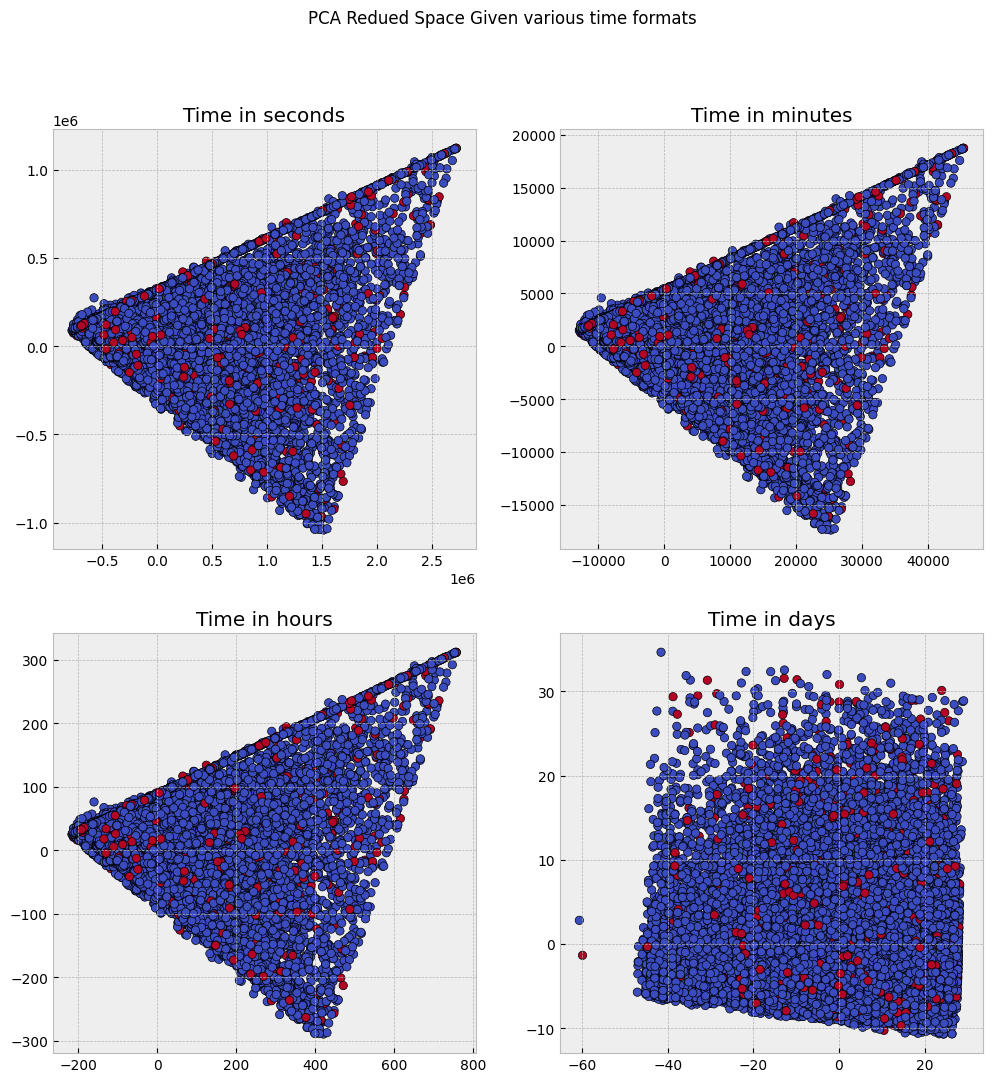

In [106]:
# Plotting PCA
fig, ax = plt.subplots(2,2, figsize=(12,12))

fig.suptitle("PCA Redued Space Given various time formats")

ax[0,0].scatter(X_pca_s[:, 0], X_pca_s[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[0,0].set_title("Time in seconds")

ax[0,1].scatter(X_pca_m[:, 0], X_pca_m[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[0,1].set_title("Time in minutes")

ax[1,0].scatter(X_pca_h[:, 0], X_pca_h[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[1,0].set_title("Time in hours")

ax[1,1].scatter(X_pca_d[:, 0], X_pca_d[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[1,1].set_title("Time in days")

plt.style.use('bmh')
plt.show()

In [107]:
feature_names = df.columns.drop('read_flag')
components = [pd.DataFrame(pca_s.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(pca_s.n_components_)]),
              pd.DataFrame(pca_m.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(pca_m.n_components_)]),
              pd.DataFrame(pca_h.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(pca_h.n_components_)]),
              pd.DataFrame(pca_d.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(pca_d.n_components_)])]
components_df = pd.concat(components)
components_df.insert(0, 'pca_type', ['seconds']*2 + ['minutes']*2 + ['hours']*2 + ['days']*2)

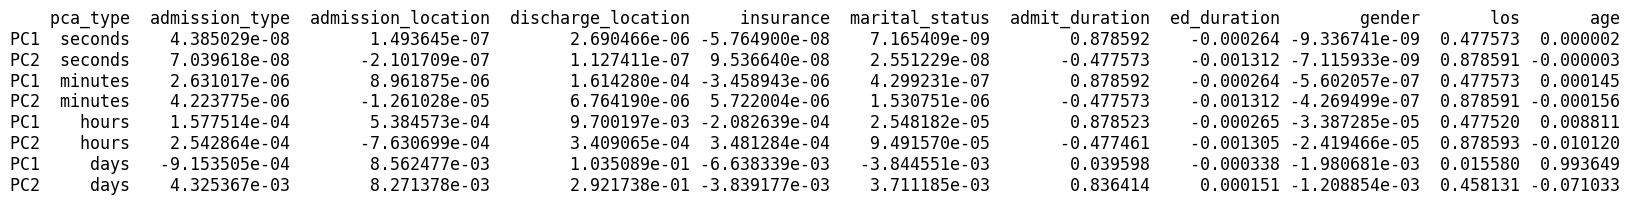

In [108]:
# Converting DataFrame
components_str = components_df.to_string()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 2))
ax.text(0, 1, components_str, fontsize=12, family='monospace', va='top')
ax.axis('off')
plt.show()